# Image Histogram Viewer
Displays a standard intensity histogram and a log-transformed histogram side by side for any image.

In [1]:
# Cell 1 — Imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Cell 2 — Point to your image
IMAGE_PATH = "your_image.tif"  # <-- change this to your image path

In [3]:
# Cell 3 — Load image and compute histograms
img = Image.open(IMAGE_PATH).convert("RGB")
img_array = np.array(img)

# Flatten all channels into one array of pixel intensities (0–255)
pixels = img_array.flatten()

# Log-transform: add 1 to avoid log(0)
pixels_log = np.log1p(pixels.astype(np.float64))

print(f"Image size : {img.size[0]} x {img.size[1]} px")
print(f"Pixel count: {len(pixels):,}")
print(f"Intensity  : min={pixels.min()}, max={pixels.max()}, mean={pixels.mean():.1f}")

Image size : 1544 x 1038 px
Pixel count: 4,808,016
Intensity  : min=0, max=255, mean=30.7


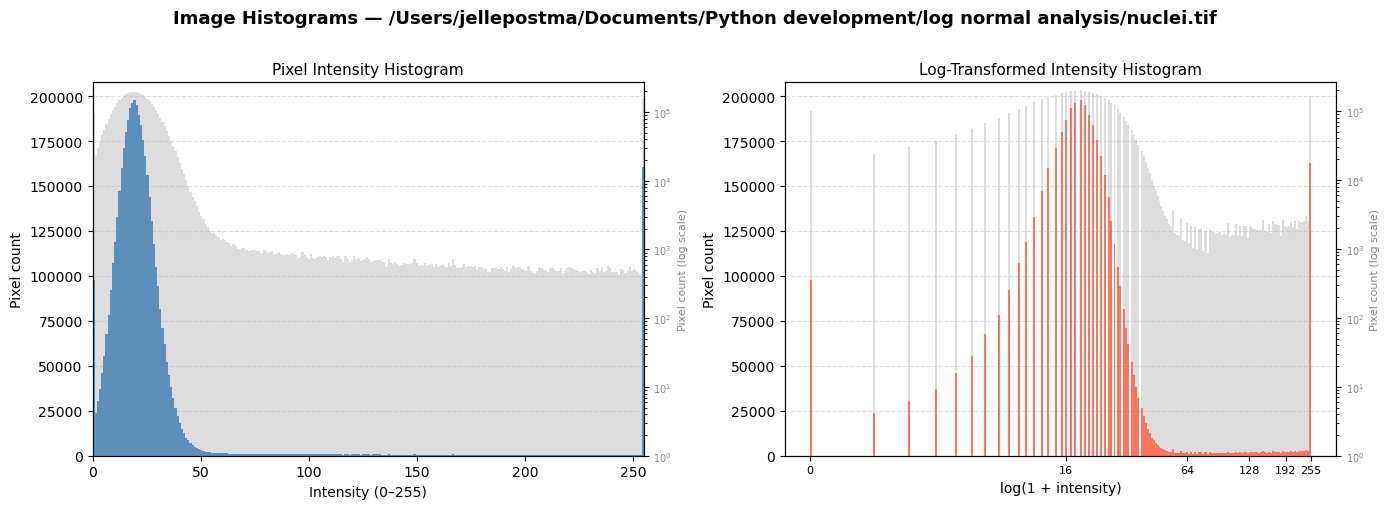

In [4]:
# Cell 4 — Plot histograms side by side (with log-y ghost overlay)

def add_logy_ghost(ax, counts, bin_edges):
    """Draw a semi-transparent grayscale log-y version of the histogram behind the main plot."""
    ax_ghost = ax.twinx()
    ax_ghost.bar(
        bin_edges[:-1], counts,
        width=np.diff(bin_edges),
        align="edge",
        color="#888888",
        alpha=0.28,
        edgecolor="none",
        log=True,
        zorder=1,
    )
    ax_ghost.set_yscale("log")
    ax_ghost.set_ylabel("Pixel count (log scale)", fontsize=8, color="#888888")
    ax_ghost.tick_params(axis="y", labelsize=7, labelcolor="#888888")
    ax_ghost.set_ylim(bottom=1)
    # Push ghost behind the main bars
    ax.set_zorder(ax_ghost.get_zorder() + 1)
    ax.patch.set_visible(False)
    return ax_ghost


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Image Histograms — {IMAGE_PATH}", fontsize=13, fontweight="bold", y=1.01)

# --- Left: standard histogram ---
ax1 = axes[0]
counts1, edges1, _ = ax1.hist(
    pixels, bins=256, range=(0, 255),
    color="steelblue", alpha=0.85, edgecolor="none", zorder=2
)
add_logy_ghost(ax1, counts1, edges1)
ax1.set_title("Pixel Intensity Histogram", fontsize=11)
ax1.set_xlabel("Intensity (0–255)")
ax1.set_ylabel("Pixel count")
ax1.set_xlim(0, 255)
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

# --- Right: log-transformed histogram ---
ax2 = axes[1]
counts2, edges2, _ = ax2.hist(
    pixels_log, bins=256,
    color="tomato", alpha=0.85, edgecolor="none", zorder=2
)
add_logy_ghost(ax2, counts2, edges2)
ax2.set_title("Log-Transformed Intensity Histogram", fontsize=11)
ax2.set_xlabel("log(1 + intensity)")
ax2.set_ylabel("Pixel count")
ax2.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

# Annotate with actual intensity values on the log x-axis
log_ticks = np.log1p([0, 16, 64, 128, 192, 255])
ax2.set_xticks(log_ticks)
ax2.set_xticklabels(["0", "16", "64", "128", "192", "255"], fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5 (optional) — Per-channel RGB histograms side by side
channels = {"Red": img_array[:, :, 0], "Green": img_array[:, :, 1], "Blue": img_array[:, :, 2]}
colors   = {"Red": "#e74c3c", "Green": "#2ecc71", "Blue": "#3498db"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Per-Channel Histograms — {IMAGE_PATH}", fontsize=13, fontweight="bold", y=1.01)

for name, ch in channels.items():
    flat = ch.flatten()

    # Standard
    axes[0].hist(flat, bins=256, range=(0, 255),
                 color=colors[name], alpha=0.55, label=name, edgecolor="none")

    # Log-transformed
    axes[1].hist(np.log1p(flat.astype(float)), bins=256,
                 color=colors[name], alpha=0.55, label=name, edgecolor="none")

for ax, title, xlabel in zip(
    axes,
    ["Per-Channel Intensity", "Per-Channel Log-Transformed Intensity"],
    ["Intensity (0–255)", "log(1 + intensity)"]
):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pixel count")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_xlim(0, 255)
axes[1].set_xticks(log_ticks)
axes[1].set_xticklabels(["0", "16", "64", "128", "192", "255"], fontsize=8)

plt.tight_layout()
plt.show()